# PHYS-467 Machine Learning for Physisicst
Fully Connected Networks - Solutions

*Exercise 1: Train a fully connected network on MNIST dataset using PyTorch. Plot the train loss and the train accuracy as a function of the number of epochs. Evaluate the generalization perfomances of the network by evaluating the test error.*

In [1]:
import numpy as np
import torch
from torchvision import transforms, datasets

In [2]:
# download MNIST dataset through torchvision PyTorch library (https://pytorch.org/vision/stable/index.html)

train = datasets.MNIST('', train=True, download=True, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(0., 1.)]))
test = datasets.MNIST('', train=False, download=True, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(0., 1.)]))

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting MNIST/raw/train-images-idx3-ubyte.gz to MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting MNIST/raw/train-labels-idx1-ubyte.gz to MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST/raw



In [3]:
from torch.utils.data import DataLoader

In [4]:
# create a Python iterable to prepare the dataset for training and testing through the torch.utils.data class (https://pytorch.org/docs/stable/data.html)

train_data_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=1)

test_data_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=1)

In [5]:
# extract the size of training and test set

trainset_shape = train_data_loader.dataset.data.shape
print("The training set has size: ", trainset_shape)

testset_shape = test_data_loader.dataset.data.shape
print("The test set has size: ", testset_shape)

The training set has size:  torch.Size([60000, 28, 28])
The test set has size:  torch.Size([10000, 28, 28])


In [6]:
import torch.nn as nn
from torch import optim

In [7]:
def train_loop(train_data_loader, model, epochs = 1000, learning_rate = 0.01, optimizer = 'SGD', loss = 'CrossEntropy'):
  """
  This function trains a neural network with SGD and its variants.
  Input: train_data_loader = iterable over the training set;
         model = neural network architecture with weights and biases;
         learning_rate = size of gradient updates;
         optimizer = which variant of gradient descent algorithm to use;
         loss = loss function.
  Output: trained neural network model and metrics stored in *.csv file. 
  """

  # select which optimizer and which loss function to use
  if loss == 'CrossEntropy':
    l = torch.nn.CrossEntropyLoss()
  if optimizer == 'SGD':
    o = optim.SGD(model.parameters(), lr=learning_rate)

  # extract the size of the training set
  size = len(train_data_loader.dataset)

  # initialize an empty dictionary
  res = {'epoch': [], 'train_loss': [], 'train_accuracy': []}

  # loop over epochs
  for e in range(epochs):
    print(f"Epoch {e+1}\n-------------------------------")

    # initialize the variables for both train loss and accuracy  
    running_loss = 0
    running_accuracy = 0.
    # loop over all batches and over all input-output pair within a batch
    for batch, (X, y) in enumerate(train_data_loader): 

        o.zero_grad() # setting gradient to zeros       
        pred = model(X) # get predictions through forward pass
        loss = l(pred, y) # compute the loss
        
        
        loss.backward() # backward propagation        
        
        o.step() # update the gradient to new gradients

    # compute the metrics of interest
        running_loss += loss.item()
        dummy_pred = torch.argmax(pred, dim = 1) # the prediction corresponds to the index pointing to the maximum score
        running_accuracy += (dummy_pred == y).float().sum() # sum only over correct predictions

        # check how the training is evolving accross the batches
        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"Processing batch n. {batch+1} ----> running loss: {running_loss/(batch + 1):>7f}, running accuracy: {running_accuracy/current:>7f} [{current:>5d}/{size:>5d}]")
    
    running_loss = running_loss/(batch + 1)
    running_accuracy = 100 * running_accuracy.numpy() / size
    print("")
    print("running training loss =  ", running_loss, " running training accuracy = ", running_accuracy)
    print("")

    res['epoch'].append(e) # populate the dictionary of results
    res['train_loss'].append(running_loss)
    res['train_accuracy'].append(running_accuracy)

  print("Done!")

  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
  res.to_csv("./metrics_over_epochs.csv", mode = 'w', index = False) # store the results into a *.csv file
  
  return

In [8]:
import pandas as pd

In [9]:
# define the neural network model
input_size = train_data_loader.dataset.data.shape[1] * train_data_loader.dataset.data.shape[2] # the MNIST is made of 28*28 pixel images. Therefore the input size of the input layer of a fully-connected network is 28*28 = 784
hidden_layers = [128,64] # number of hidden layers and hidden units
output_size = 10 # total number of classes = size of the output layer

# instantiate the sequential contrainer to stack the network layers (https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) through torch.nn (https://pytorch.org/docs/stable/nn.html)
model = nn.Sequential( 
    nn.Flatten(), # reshape the 28*28 matrix of pixels into an array of length 784 (https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)
    nn.Linear(input_size, hidden_layers[0]),
    nn.ReLU(),
    nn.Linear(hidden_layers[0], hidden_layers[1]),
    nn.ReLU(),
    nn.Linear(hidden_layers[1], output_size)
)

# define the hyper-parameters of the network training
epochs = 10
learning_rate = 0.01
optimizer = 'SGD'
loss = 'CrossEntropy'

# train the network
train_loop(train_data_loader, model, epochs = epochs, learning_rate = learning_rate, optimizer = optimizer, loss = loss)

Epoch 1
-------------------------------
Processing batch n. 1 ----> running loss: 2.298220, running accuracy: 0.156250 [   64/60000]
Processing batch n. 101 ----> running loss: 2.295214, running accuracy: 0.142327 [ 6464/60000]
Processing batch n. 201 ----> running loss: 2.280086, running accuracy: 0.195740 [12864/60000]
Processing batch n. 301 ----> running loss: 2.259090, running accuracy: 0.274242 [19264/60000]
Processing batch n. 401 ----> running loss: 2.228885, running accuracy: 0.334983 [25664/60000]
Processing batch n. 501 ----> running loss: 2.185101, running accuracy: 0.383327 [32064/60000]
Processing batch n. 601 ----> running loss: 2.119519, running accuracy: 0.423669 [38464/60000]
Processing batch n. 701 ----> running loss: 2.030637, running accuracy: 0.461818 [44864/60000]
Processing batch n. 801 ----> running loss: 1.929590, running accuracy: 0.496294 [51264/60000]
Processing batch n. 901 ----> running loss: 1.828594, running accuracy: 0.525770 [57664/60000]

running tra

In [10]:
# extract the weights and biases of the network 
for p in model.parameters():
  print(p)

Parameter containing:
tensor([[-0.0041,  0.0340,  0.0011,  ...,  0.0020,  0.0299,  0.0314],
        [-0.0230, -0.0248,  0.0084,  ..., -0.0356,  0.0120, -0.0317],
        [-0.0250, -0.0117,  0.0179,  ...,  0.0276,  0.0091,  0.0091],
        ...,
        [-0.0217,  0.0135,  0.0325,  ...,  0.0082,  0.0274, -0.0202],
        [ 0.0196,  0.0207, -0.0287,  ...,  0.0078, -0.0028,  0.0347],
        [-0.0286, -0.0224,  0.0249,  ..., -0.0219, -0.0010, -0.0079]],
       requires_grad=True)
Parameter containing:
tensor([-1.2594e-02,  2.1667e-02,  7.2027e-02,  3.0239e-02,  4.8572e-02,
         6.3971e-02,  9.5801e-03,  2.0117e-02,  1.2936e-02,  6.4557e-02,
        -3.8052e-03, -7.5441e-02, -1.8939e-02,  1.2900e-02,  4.6996e-02,
         9.6456e-02, -8.8260e-04,  2.2381e-03, -1.8050e-02,  1.1277e-02,
         5.0669e-02, -1.3371e-02,  1.2870e-02,  3.2889e-02,  3.2006e-02,
         4.6753e-02,  1.0663e-01,  2.1469e-02,  2.8647e-02, -1.2312e-02,
         2.0544e-02,  4.0539e-02,  1.0789e-01,  8.9894e-0

In [11]:
import matplotlib.pyplot as plt
import matplotlib

(-1.0, 10.0)

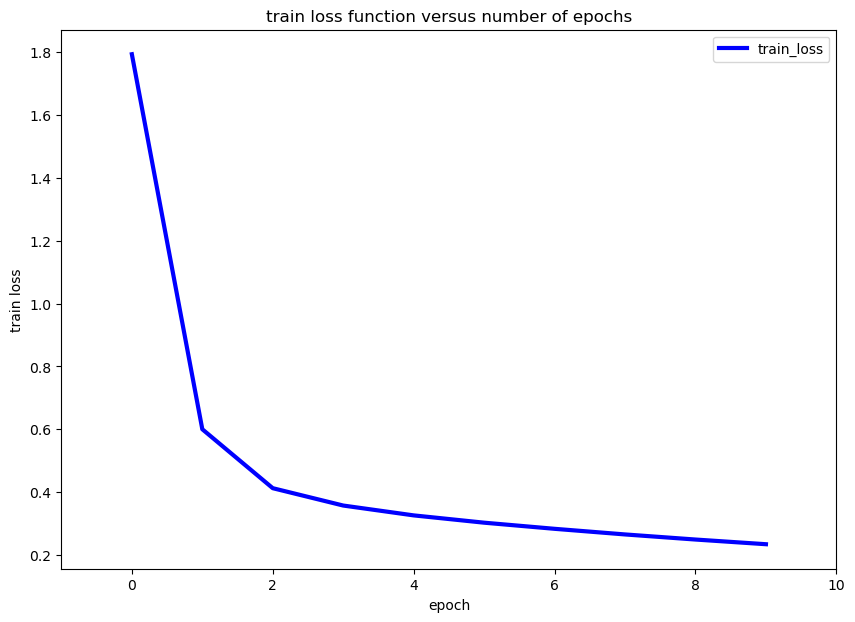

In [12]:
# plot the train loss as a function of the number of epochs

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./metrics_over_epochs.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_loss',
         color = 'blue',
         lw = 3, # linewidth
         ax=ax) # plot the results with matplotlib through pandas

ax.set_title("train loss function versus number of epochs") # set the plot title
ax.set_ylabel("train loss") # set the name of the y axis
ax.set_xlabel("epoch") # set the name of the x axis
ax.set_xlim(-1, 10)

(-1.0, 10.0)

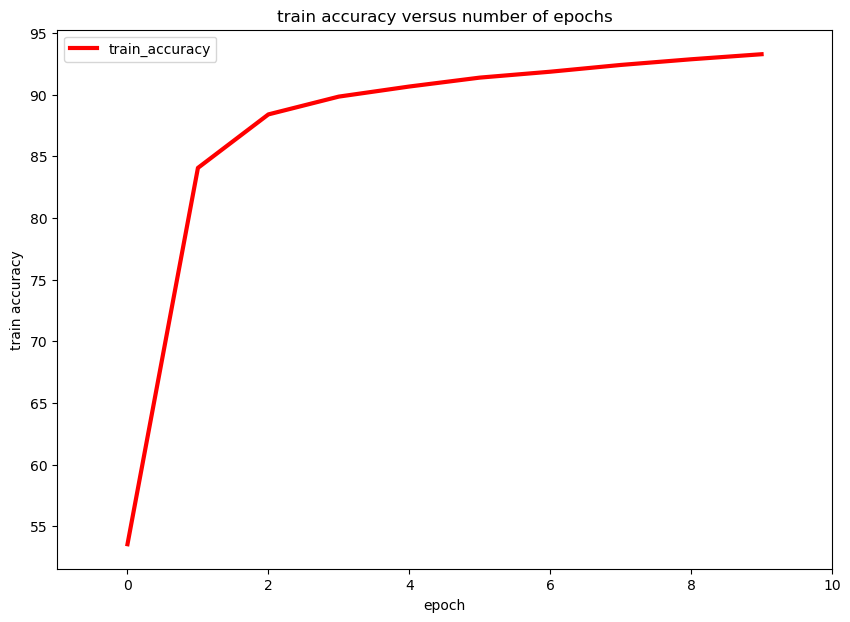

In [13]:
# plot the train accuracy as a function of the number of epochs

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./metrics_over_epochs.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_accuracy',
         color = 'red',
         lw = 3, # linewidth
         ax=ax) # plot the results with matplotlib through pandas

ax.set_title("train accuracy versus number of epochs") # set the plot title
ax.set_ylabel("train accuracy") # set the name of the y axis
ax.set_xlabel("epoch") # set the name of the x axis
ax.set_xlim(-1, 10)

In [18]:
def check_mistakes_last_batch(X, y, dummy_pred):
  """
  This function checks the mistakes the network does on the last batch of the test set. 
  Input: (X,y) = last batch of examples;
         dummy_pred = prediction of the network in dummy format.
  Output: check whether there are mistakes, and if there are plot the image corresponding to the mistake done by the network with its own label and the network prediction 
  """

  mistakes = dummy_pred.numpy() != y.numpy() # detect the mistakes
  Xm = X[mistakes].numpy() # select only those examples for which the network makes a mistake
  ym = y[mistakes].numpy()
  dummy_predm = dummy_pred[mistakes].numpy()
  n_mistakes = len(np.where(mistakes)[0]) # count the number of mistakes

  print(f'{n_mistakes} mistakes in last batch')

  if n_mistakes == 0: # if there are no mistakes return
    print("No mistakes in the last batch")
  else: # if there are mistakes plot the images corresponding to the mistake, together with its label and the corresponding network prediction            
    for i in range(n_mistakes):  
      plt.subplot(3, 3,  i + 1) # create the plot container
      plt.imshow(Xm[i][0], cmap=plt.get_cmap('gray')) # plot the image
      plt.tight_layout(pad = 0.3) # add space between subplots
      plt.title("y = " + str(ym[i]) + " " + "pred = " + str(dummy_predm[i]), color = 'red') # print labels and predictions as a title of the plot
      plt.show()
  return

In [15]:
def test_loop(test_data_loader, model, loss = 'CrossEntropy'):

  # initialize the variables for both test loss and accuracy 
  test_loss = 0.
  test_accuracy = 0.
  
  # select which loss function to use
  if loss == 'CrossEntropy':
    l = torch.nn.CrossEntropyLoss()

  # extract the size of the test set
  size = len(test_data_loader.dataset)

  # create the container to avoid gradient computation
  with torch.no_grad():
    # loop over all test input-output pairs
    for X, y in test_data_loader: 
        
        pred = model(X) # get predictions through forward pass
        loss = l(pred, y) # compute the loss
        
    # compute the metrics of interest    
        test_loss += loss.item()
        dummy_pred = torch.argmax(pred, dim = 1) # the prediction corresponds to the index pointing to the maximum score
        test_accuracy += (dummy_pred == y).float().sum() # sum only over correct predictions 

  test_loss = test_loss/len(test_data_loader)
  test_accuracy = 100 * test_accuracy.numpy() / size
  print("test loss =  ", test_loss, "test accuracy = ", test_accuracy)
  return X, y, dummy_pred

In [16]:
X, y, dummy_pred = test_loop(test_data_loader, model, loss = 'CrossEntropy')

test loss =   0.22097161527912898 test accuracy =  93.67


1 mistakes in last batch


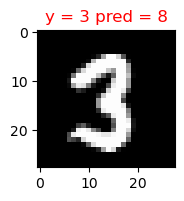

In [19]:
check_mistakes_last_batch(X, y, dummy_pred)

*Exercise 2: Repeat exercise n.1 with SUSY dataset.*

In [20]:
# download the SUSY dataset and upload it in Google Colab

import os

os.system('wget https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz')
os.system('gunzip "/content/SUSY.csv.gz"')

sh: wget: command not found
gunzip: can't stat: /content/SUSY.csv.gz (/content/SUSY.csv.gz.gz): No such file or directory


256

In [19]:
# class to load the SUSY dataset

class SUSY_Dataset(torch.utils.data.Dataset):
    """SUSY pytorch dataset."""

    def __init__(self, data_file, root_dir, dataset_size, train=True, transform=None, high_level_feats=None):
        """
        This method loads the dataset from the SUSY.csv file and store the input-output pair in a tuple.
        Inputs:
            csv_file (string)= Path to the csv file with annotations.
            root_dir (string)= Directory with all the images.
            train (bool, optional)= If set to `True` load training data.
            transform (callable, optional)= Optional transform to be applied on a sample.
            high_level_festures (bool, optional): If set to `True`, working with high-level features only. 
                                        If set to `False`, working with low-level features only.
                                        Default is `None`: working with all features
        Output: data = (input,label) tuple.
        """

        import pandas as pd

        # define feature names

        features=['SUSY','lepton 1 pT', 'lepton 1 eta', 'lepton 1 phi', 'lepton 2 pT', 'lepton 2 eta', 'lepton 2 phi', 
                'missing energy magnitude', 'missing energy phi', 'MET_rel', 'axial MET', 'M_R', 'M_TR_2', 'R', 'MT2', 
                'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos(theta_r1)']

        low_features=['lepton 1 pT', 'lepton 1 eta', 'lepton 1 phi', 'lepton 2 pT', 'lepton 2 eta', 'lepton 2 phi', 
                'missing energy magnitude', 'missing energy phi']

        high_features=['MET_rel', 'axial MET', 'M_R', 'M_TR_2', 'R', 'MT2','S_R', 'M_Delta_R', 'dPhi_r_b', 'cos(theta_r1)']


        # read the content of the SUSY.csv file through Pandas

        df = pd.read_csv(root_dir+data_file, header=None,nrows=dataset_size,engine='python')
        df.columns=features # assign columns names according to features names
        Y = df['SUSY'] # assign labels
        X = df[[col for col in df.columns if col!="SUSY"]] # assign inputs

        # set training and test data size
        train_size=int(0.8*dataset_size)
        self.train=train

        # train/test split
        if self.train:
            X=X[:train_size]
            Y=Y[:train_size]
            print("Training on {} examples".format(train_size))
        else:
            X=X[train_size:]
            Y=Y[train_size:]
            print("Testing on {} examples".format(dataset_size-train_size))


        self.root_dir = root_dir
        self.transform = transform

        # decides which features to use
        if high_level_feats is None:
            self.data=(X.values.astype(np.float32),Y.values.astype(int))
            print("Using both high and low level features")
        elif high_level_feats is True:
            self.data=(X[high_features].values.astype(np.float32),Y.values.astype(int))
            print("Using both high-level features only.")
        elif high_level_feats is False:
            self.data=(X[low_features].values.astype(np.float32),Y.values.astype(int))
            print("Using both low-level features only.")



    def __len__(self): # method to compute the length of the dataset
        return len(self.data[1])

    def __getitem__(self, idx): # method to iterate over examples in the dataset

        sample=(self.data[0][idx,...],self.data[1][idx])

        if self.transform: # decide whether to apply transformations to the dataset or not
            sample=self.transform(sample)

        return sample

In [20]:
# Use the SUSY dataset class to load data in a format suitable to PyTorch

training_data = SUSY_Dataset(
    data_file='SUSY.csv',
    root_dir='./',
    dataset_size=70000,
    train=True,
    high_level_feats=None
    )

test_data = SUSY_Dataset(
    data_file='SUSY.csv',
    root_dir='./',
    dataset_size=70000,
    train=False,
    high_level_feats=None
    )



Training on 56000 examples
Using both high and low level features
Testing on 14000 examples
Using both high and low level features


In [21]:
# create a Python iterable to prepare the dataset for training and testing through the torch.utils.data class

train_data_loader = DataLoader(training_data, batch_size=100, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=100)

In [22]:
# extract the size of training and test set
train_set_shape = train_data_loader.dataset.data[0].shape
print("The size of the training set is = ", train_set_shape)

test_set_shape = test_data_loader.dataset.data[0].shape
print("The size of the training set is = ", test_set_shape)

The size of the training set is =  (56000, 18)
The size of the training set is =  (14000, 18)


In [23]:
# define the neural network model
input_size = train_data_loader.dataset.data[0].shape[1]
hidden_layers = [128,64]
output_size = 2

# instantiate the sequential contrainer to stack the network layers
model = nn.Sequential( 
    nn.Linear(input_size, hidden_layers[0]),
    nn.ReLU(),
    nn.Linear(hidden_layers[0], hidden_layers[1]),
    nn.ReLU(),
    nn.Linear(hidden_layers[1], output_size)
)

# define the hyper-parameters of the network training

epochs = 5
learning_rate = 0.01
optimizer = 'SGD'
loss = 'CrossEntropy'

train_loop(train_data_loader, model, epochs = epochs, learning_rate = learning_rate, optimizer = optimizer, loss = loss)

Epoch 1
-------------------------------
Processing batch n. 1 ----> running loss: 0.697677, running accuracy: 0.560000 [  100/56000]
Processing batch n. 101 ----> running loss: 0.683988, running accuracy: 0.577624 [10100/56000]
Processing batch n. 201 ----> running loss: 0.670646, running accuracy: 0.626915 [20100/56000]
Processing batch n. 301 ----> running loss: 0.656546, running accuracy: 0.660066 [30100/56000]
Processing batch n. 401 ----> running loss: 0.643475, running accuracy: 0.677007 [40100/56000]
Processing batch n. 501 ----> running loss: 0.630401, running accuracy: 0.690259 [50100/56000]

running training loss =   0.6224585093557835  running training accuracy =  69.68571428571428

Epoch 2
-------------------------------
Processing batch n. 1 ----> running loss: 0.558923, running accuracy: 0.770000 [  100/56000]
Processing batch n. 101 ----> running loss: 0.545618, running accuracy: 0.744455 [10100/56000]
Processing batch n. 201 ----> running loss: 0.534633, running accurac

Text(0.5, 0, 'epoch')

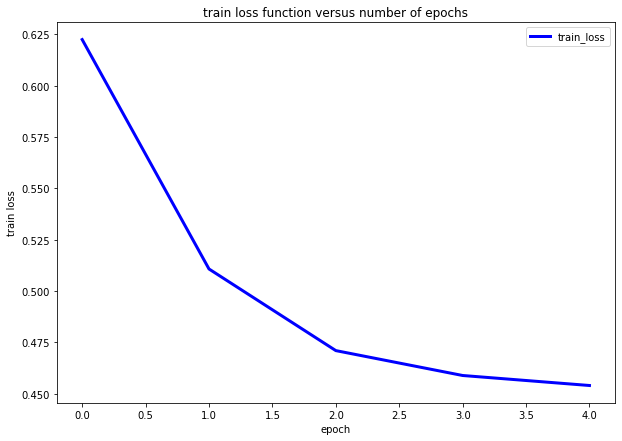

In [24]:
# Plote the training loss as a function of the number of epochs

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./metrics_over_epochs.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_loss',
         color = 'blue',
         lw = 3, # linewidth
         ax=ax) # plot the results with matplotlib through pandas

ax.set_title("train loss function versus number of epochs") # set the plot title
ax.set_ylabel("train loss") # set the name of the y axis
ax.set_xlabel("epoch") # set the name of the x axis


Text(0.5, 0, 'epoch')

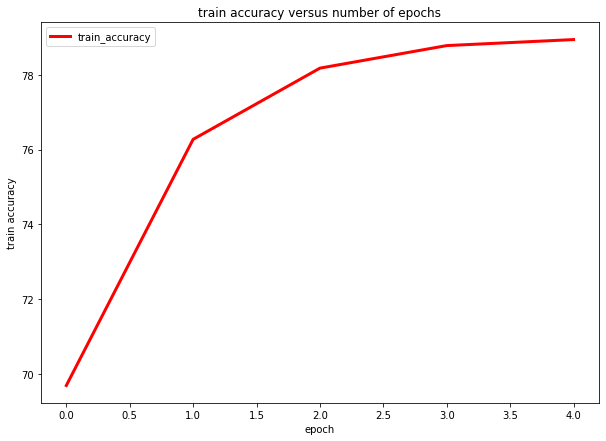

In [25]:
# Plot the train accuracy as a function of the number of epochs

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./metrics_over_epochs.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_accuracy',
         color = 'red',
         lw = 3, # linewidth
         ax=ax) # plot the results with matplotlib through pandas

ax.set_title("train accuracy versus number of epochs") # set the plot title
ax.set_ylabel("train accuracy") # set the name of the y axis
ax.set_xlabel("epoch") # set the name of the x axis


In [26]:
# compute the metrics on the test set

_ = test_loop(test_data_loader, model, loss = 'CrossEntropy')

test loss =   0.45101826936006545 test accuracy =  79.13571428571429
